# Cell 1 _ Importing libraries

In [2]:
import os
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight
import cv2

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-06-27 19:01:13.968015: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782586874.135650      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782586874.182997      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782586874.548696      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782586874.548733      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782586874.548736      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Cell 2 _ Verifying dataset structure

In [3]:
print("Top level:", os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/'))

Top level: ['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [4]:
base = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia'
print("At base level:", os.listdir(base))
print()
print("Inside chest_xray/:", os.listdir(os.path.join(base, 'chest_xray')))

At base level: ['chest_xray']

Inside chest_xray/: ['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [5]:
outer_path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'

print("Outer train/:", os.listdir(os.path.join(outer_path, 'train')))
print()

inner_path = os.path.join(outer_path, 'chest_xray')
print("Inner train/:", os.listdir(os.path.join(inner_path, 'train')))

Outer train/: ['PNEUMONIA', 'NORMAL']

Inner train/: ['PNEUMONIA', 'NORMAL', '.DS_Store']


In [6]:
base_path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'

train_dir = os.path.join(base_path, 'train')
val_dir   = os.path.join(base_path, 'val')
test_dir  = os.path.join(base_path, 'test')

print("Image counts:")
for split_name, split_path in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
    for cls in ['NORMAL', 'PNEUMONIA']:
        count = len(os.listdir(os.path.join(split_path, cls)))
        print(f"  {split_name}/{cls}: {count} images")

Image counts:
  train/NORMAL: 1341 images
  train/PNEUMONIA: 3875 images
  val/NORMAL: 8 images
  val/PNEUMONIA: 8 images
  test/NORMAL: 234 images
  test/PNEUMONIA: 390 images


In [7]:
train_count_normal = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
train_count_pneumonia = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
imbalance_ratio = train_count_pneumonia / train_count_normal
print(f"Train imbalance ratio (pneumonia:normal): {imbalance_ratio:.2f}:1")

Train imbalance ratio (pneumonia:normal): 2.89:1


# Cell 3 _ Data generators with our own validation split

In [8]:
IMG_SIZE = 224   # DenseNet121's standard input size
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.15   # carve 15% out of train, ignore the tiny provided val/
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)
print("Train batches:", len(train_gen))
print("Val batches:  ", len(val_gen))
print("Test batches: ", len(test_gen))

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train batches: 139
Val batches:   25
Test batches:  20


# Cell 4 _ Calculate class weights

In [9]:
class_labels = train_gen.classes

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)

class_weights = dict(enumerate(class_weights_array))

print("Class weights:")
print(f" NORMAL (class 0): {class_weights[0]:.3f}")
print(f" PNEUMONIA (class 1): {class_weights[1]:.3f}")

Class weights:
 NORMAL (class 0): 1.945
 PNEUMONIA (class 1): 0.673


# Cell 5 _ Building the model with DenseNet121(frozen_base)

In [10]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

model.summary()

I0000 00:00:1782586893.793581      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782586893.799475      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,301,185 (27.85 MB)

 Trainable params: 263,169 (1.00 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

# Cell 6 _ Phase one of training (frozen-base) & watching recall live 

In [12]:
callbacks_phase1 = [
    EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history_frozen = model.fit(
    train_gen,
    epochs=12,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    class_weight=class_weights
)

baseline_results = model.evaluate(val_gen)
print(f"\nFrozen-base — Val accuracy: {baseline_results[1]*100:.2f}%, Val recall: {baseline_results[2]*100:.2f}%, Val precision: {baseline_results[3]*100:.2f}%")



Epoch 1/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.8906 - loss: 0.2242 - precision: 0.9872 - recall: 0.8640 - val_accuracy: 0.9450 - val_loss: 0.1389 - val_precision: 0.9891 - val_recall: 0.9363 - learning_rate: 0.0010
Epoch 2/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 92s 663ms/step - accuracy: 0.9495 - loss: 0.1295 - precision: 0.9898 - recall: 0.9417 - val_accuracy: 0.8683 - val_loss: 0.3287 - val_precision: 1.0000 - val_recall: 0.8227 - learning_rate: 0.0010
Epoch 3/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 91s 656ms/step - accuracy: 0.9549 - loss: 0.1132 - precision: 0.9883 - recall: 0.9505 - val_accuracy: 0.9642 - val_loss: 0.0948 - val_precision: 0.9775 - val_recall: 0.9742 - learning_rate: 0.0010
Epoch 4/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 91s 655ms/step - accuracy: 0.9571 - loss: 0.1097 - precision: 0.9874 - recall: 0.9545 - val_accuracy: 0.9501 - val_loss: 0.1361 - val_precision: 0.9927 - val_recall: 0.9398 - learning_rate: 0.0010
Epoch 5/12
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step 

# Cell 2 _ Phase 2 : unfreezing and fine-tuning

In [18]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_recall', mode='max', patience=6,restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('/kaggle/working/best_pneumonia_model.h5', monitor='val_recall', mode='max', save_best_only=True, verbose=1)
]

history_finetuned = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    class_weight=class_weights
    )


Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.9486 - loss: 0.1489 - precision: 0.9745 - recall: 0.9557
Epoch 1: val_recall improved from None to 0.93804, saving model to /kaggle/working/best_pneumonia_model.h5



Epoch 1: finished saving model to /kaggle/working/best_pneumonia_model.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 155s 903ms/step - accuracy: 0.9470 - loss: 0.1524 - precision: 0.9772 - recall: 0.9508 - val_accuracy: 0.9488 - val_loss: 0.1285 - val_precision: 0.9927 - val_recall: 0.9380 - learning_rate: 1.0000e-05
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.9535 - loss: 0.1416 - precision: 0.9806 - recall: 0.9560
Epoch 2: val_recall did not improve from 0.93804
139/139 ━━━━━━━━━━━━━━━━━━━━ 92s 661ms/step - accuracy: 0.9529 - loss: 0.1380 - precision: 0.9825 - recall: 0.9536 - val_accuracy: 0.9488 - val_loss: 0.1342 - val_precision: 0.9927 - val_recall: 0.9380 - learning_rate: 1.0000e-05
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.9547 - loss: 0.1306 - precision: 0.9778 - recall: 0.9598
Epoch 3: val_recall did not improve from 0.93804
139/139 ━━━━━━━━━━━━━━━━━━━━ 93s 666ms/step - accuracy: 0.9544 - loss: 0.1258 - precision: 0.9834 - recall: 0.9548 -


Epoch 5: finished saving model to /kaggle/working/best_pneumonia_model.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 94s 676ms/step - accuracy: 0.9587 - loss: 0.1075 - precision: 0.9856 - recall: 0.9584 - val_accuracy: 0.9552 - val_loss: 0.1239 - val_precision: 0.9910 - val_recall: 0.9484 - learning_rate: 5.0000e-06
Epoch 6/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.9602 - loss: 0.1023 - precision: 0.9914 - recall: 0.9556
Epoch 6: val_recall improved from 0.94836 to 0.95697, saving model to /kaggle/working/best_pneumonia_model.h5



Epoch 6: finished saving model to /kaggle/working/best_pneumonia_model.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 94s 673ms/step - accuracy: 0.9610 - loss: 0.1036 - precision: 0.9884 - recall: 0.9587 - val_accuracy: 0.9591 - val_loss: 0.1223 - val_precision: 0.9876 - val_recall: 0.9570 - learning_rate: 5.0000e-06
Epoch 7/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.9582 - loss: 0.1090 - precision: 0.9860 - recall: 0.9572
Epoch 7: val_recall did not improve from 0.95697
139/139 ━━━━━━━━━━━━━━━━━━━━ 94s 678ms/step - accuracy: 0.9594 - loss: 0.1085 - precision: 0.9884 - recall: 0.9566 - val_accuracy: 0.9527 - val_loss: 0.1208 - val_precision: 0.9910 - val_recall: 0.9449 - learning_rate: 5.0000e-06
Epoch 8/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.9544 - loss: 0.1102 - precision: 0.9856 - recall: 0.9523
Epoch 8: val_recall did not improve from 0.95697
139/139 ━━━━━━━━━━━━━━━━━━━━ 92s 667ms/step - accuracy: 0.9553 - loss: 0.1027 - precision: 0.9886 - recall: 0.9508 - 

# Cell 8 _ Comparing frozen vs fine_tuned & saving **accuracy/recall/precision**

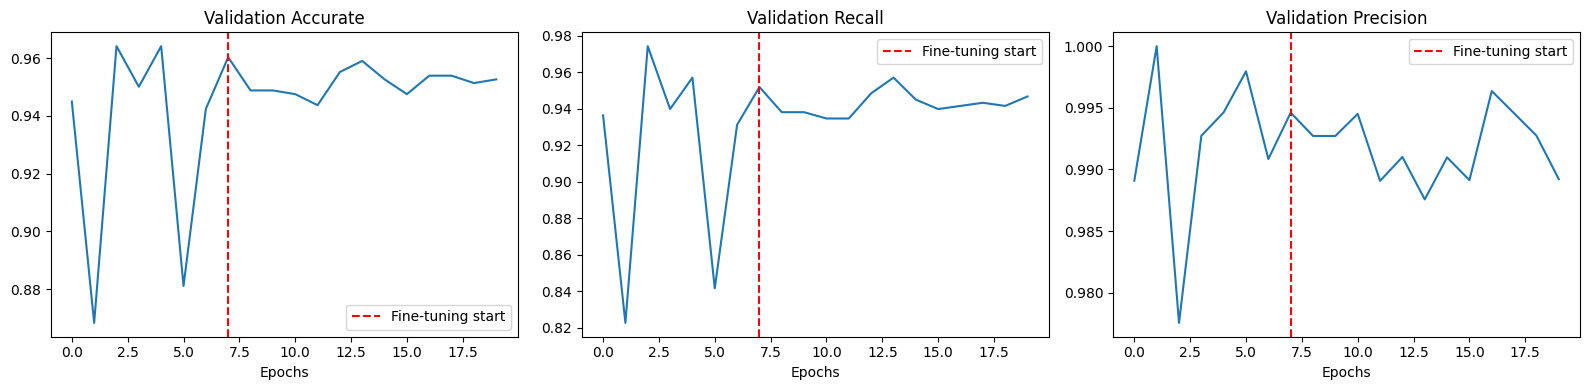

Frozen-base best val recall:   97.42%
Fine-tuned best val recall: 95.70%


In [19]:
acc_frozen = history_frozen.history['val_accuracy']
acc_finetuned = history_finetuned.history['val_accuracy']
all_acc = acc_frozen + acc_finetuned

recall_frozen = history_frozen.history['val_recall']
recall_finetuned = history_finetuned.history['val_recall']
all_recall = recall_frozen + recall_finetuned

precision_frozen = history_frozen.history['val_precision']
precision_finetuned = history_finetuned.history['val_precision']
all_precision = precision_frozen + precision_finetuned

fig, axes = plt.subplots(1, 3, figsize=(16,4))

for ax, data, title in zip(axes, [all_acc, all_recall, all_precision], ['Accurate', 'Recall', 'Precision']):
    ax.plot(data)
    ax.axvline(x=len(acc_frozen)-1, color='red', linestyle='--', label='Fine-tuning start')
    ax.set_title(f'Validation {title}')
    ax.set_xlabel('Epochs')
    ax.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Frozen-base best val recall:   {max(recall_frozen)*100:.2f}%")
print(f"Fine-tuned best val recall: {max(recall_finetuned)*100:.2f}%")

# Cell 9 _ Evaluating on the real test set + confusion matrix

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.9054 - loss: 0.2900 - precision: 0.9007 - recall: 0.9538

Test accuracy:  90.54%
Test recall:  95.38%  (catches this % of actual pneumonia cases)
Test precision:  90.07%  (this % of 'pneumonia prediction are correct'
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 224ms/step


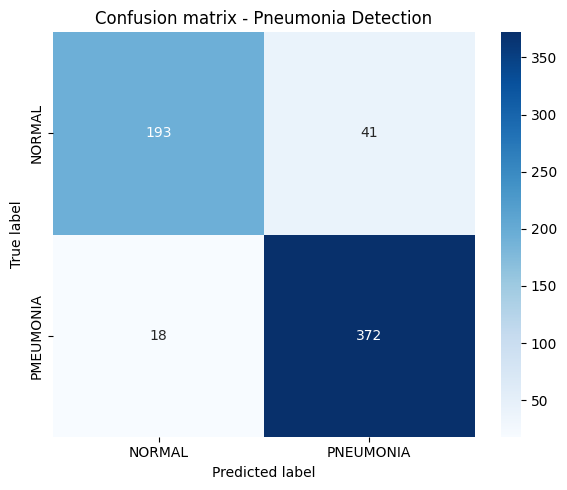


Classification report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.82      0.87       234
   PNEUMONIA       0.90      0.95      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.89      0.90       624
weighted avg       0.91      0.91      0.90       624



In [22]:
test_results = model.evaluate(test_gen)
test_loss, test_acc, test_recall, test_precision = test_results

print(f"\nTest accuracy:  {test_acc*100:.2f}%")
print(f"Test recall:  {test_recall*100:.2f}%  (catches this % of actual pneumonia cases)")
print(f"Test precision:  {test_precision*100:.2f}%  (this % of 'pneumonia prediction are correct'")

y_pred_probs = model.predict(test_gen)
y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PMEUMONIA'])
plt.title('Confusion matrix - Pneumonia Detection')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification report:")
print(classification_report(y_true, y_pred_classes, target_names=['NORMAL', 'PNEUMONIA']))

# Cell 10 _ BUilding Grad-CAM, the explainability centerpiece of this project

In [30]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Find the name of the last convolutional layer in DenseNet121
for layer in reversed(base_model.layers):
    if 'conv' in layer.name.lower():
        last_conv_layer_name = layer.name
        break

print(f"USing last conv layer: {last_conv_layer_name}")

USing last conv layer: conv5_block16_concat


# Cell 11 _ Generating & Visualizing the Grad-CAM overlay

In [40]:
def display_gradcam(img_path, model, last_conv_layer_name, img_size=224):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_size, img_size))
    img_array_original = tf.keras.preprocessing.image.img_to_array(img)
    
    # Make an explicit COPY before preprocessing, so the original stays clean for display
    img_array_for_model = img_array_original.copy()
    img_array_processed = preprocess_input(np.expand_dims(img_array_for_model, axis=0))

    pred = model.predict(img_array_processed, verbose=0)[0][0]
    pred_label = 'PNEUMONIA' if pred > 0.5 else 'NORMAL'
    confidence = pred if pred > 0.5 else 1 - pred

    heatmap = get_gradcam_heatmap(model, img_array_processed, last_conv_layer_name)

    heatmap_resized = cv2.resize(heatmap, (img_size, img_size))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = heatmap_colored.astype('float32') * 0.4 + img_array_original.astype('float32') * 0.6
    superimposed = np.clip(superimposed, 0, 255).astype('uint8')

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    axes[0].imshow(img_array_original.astype('uint8'))
    axes[0].set_title('Original X-ray')
    axes[0].axis('off')

    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title('Grad-CAM heatmap')
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    axes[2].set_title(f'Overlay — Predicted: {pred_label} ({confidence*100:.1f}%)')
    axes[2].axis('off')

    plt.tight_layout()
    return fig

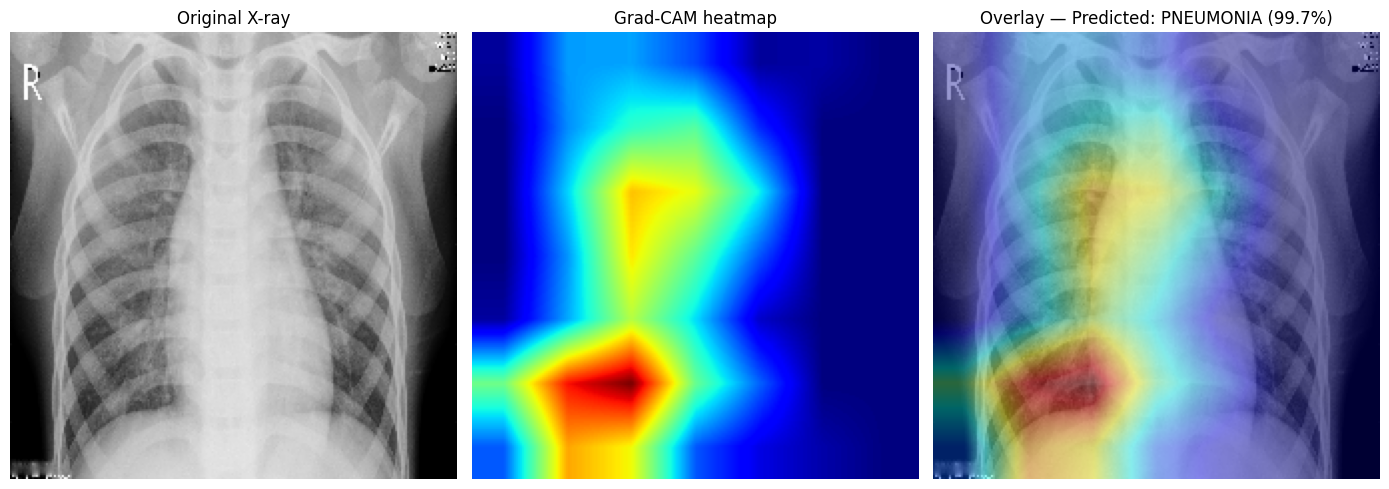

In [41]:
fig = display_gradcam(sample_path, model, last_conv_layer_name)
plt.savefig('/kaggle/working/gradcam_pneumonia_example.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell 12 _ Grad-CAM on a NORMAL X-ray for contrast

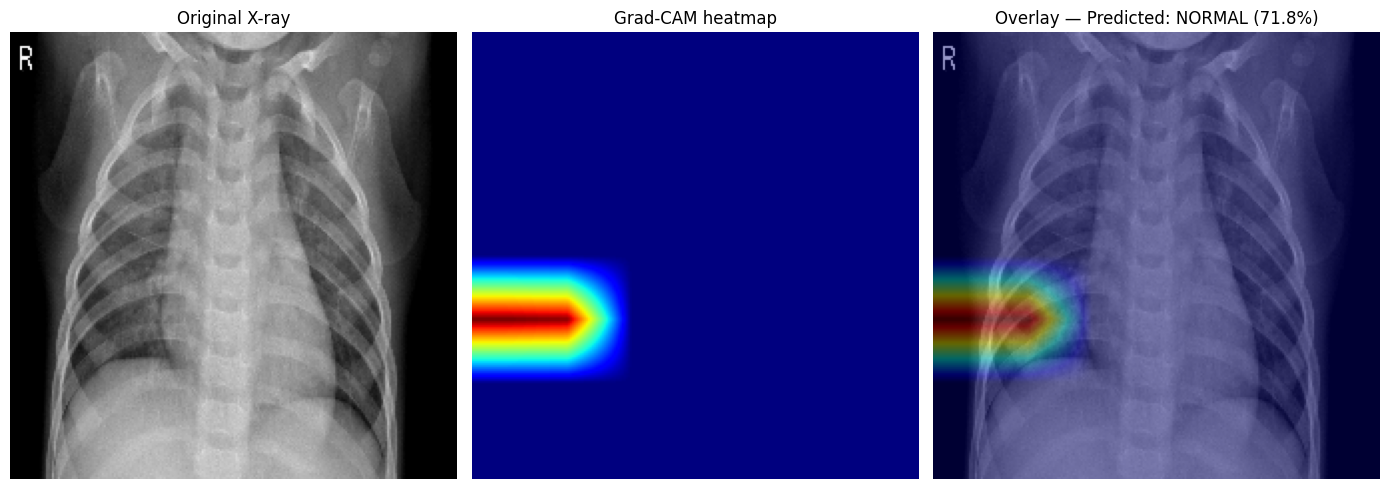

In [42]:
normal_dir = os.path.join(test_dir, 'NORMAL')
sample_normal = os.listdir(normal_dir)[0]
sample_normal_path = os.path.join(normal_dir, sample_normal)

fig = display_gradcam(sample_normal_path, model, last_conv_layer_name)
plt.savefig('/kaggle/working/gradcam_normal_example.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell 13 _ Saving the model

In [44]:
model.save('/kaggle/working/pneumonia_model.h5')
print("Model saved!")
print(f"File size: {os.path.getsize('/kaggle/working/pneumonia_model.h5') / (1024*1024):.2f} MB")

Model saved!
File size: 36.05 MB
